# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
#data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\test_logging_data\\log_202404091537.csv"
#data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\test_logging_data\\log_202404101626.csv"
#data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\test_logging_data\\log_202404101814.csv"
#data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\test_logging_data\\log_202404121758.csv"
#data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\test_logging_data\\log_202404121736.csv"
#data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\test_logging_data\\log_202404121744.csv"
#data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\test_logging_data\\log_202404121748.csv"
#data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\test_logging_data\\log_202404121816.csv"
data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\60_degree_y_z_direction_06.05\\log_202405061534.csv"
data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\60_degree_y_z_direction_06.05\\log_202405061536.csv"
data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\60_degree_y_z_direction_06.05\\log_202405061540.csv"
data = "C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor's Thesis\\07_Test\\60_degree_y_z_direction_06.05\\log_202405061548.csv"
data = "../raw_data/Gripper Test Hook//Asphalt_Revolution_5N//log_202406031155.csv"
#data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_50_5N//log_202405232046.csv"


df = pd.read_csv(data)

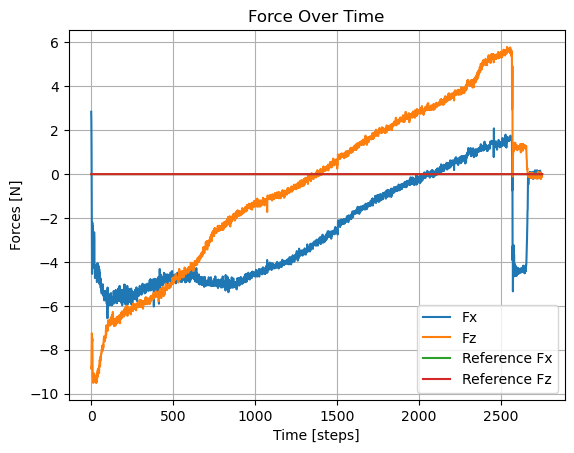

In [14]:
# plt.plot(df.Fx, label = "Fx")
# plt.plot(df.Fy, label = "Fy")
# plt.plot(df.Fz, label = "Fz")
plt.plot(df.Fx-df.Fx.iloc[-1], label = "Fx")
#plt.plot(df.Fy-df.Fy.iloc[-1], label = "Fy")
plt.plot(df.Fz-df.Fz.iloc[-1], label = "Fz")
plt.plot(df.ref_Fx, label="Reference Fx")
#plt.plot(df.ref_Fy, label="Reference Fy")
plt.plot(df.ref_Fz, label="Reference Fz")
plt.title("Force Over Time")
plt.xlabel("Time [steps]")
plt.ylabel("Forces [N]")
plt.legend()
plt.grid()

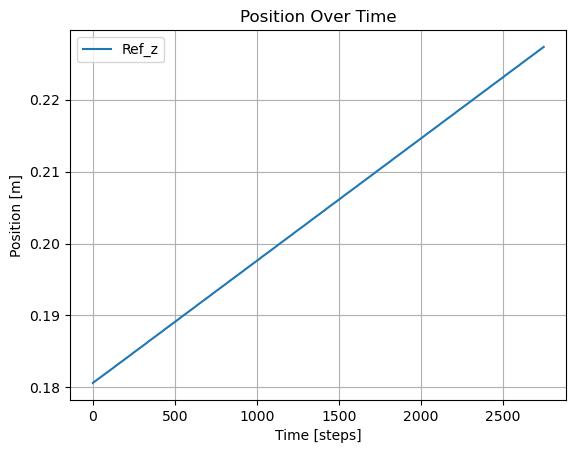

In [15]:
#plt.plot(df.x - df.x[1], label = "x")
#plt.plot(df.y - df.y[1], label = "y")
#plt.plot(df.z - df.z[1], label = "z")
#plt.plot(df.ref_x, label="Ref_x")
#plt.plot(df.ref_y, label="Ref_y")
plt.plot(df.ref_z, label="Ref_z")
plt.title("Position Over Time")
plt.xlabel("Time [steps]")
plt.ylabel("Position [m]")
plt.legend()
plt.grid()

In [16]:
print(df.ref_z)

0       0.180610
1       0.180626
2       0.180643
3       0.180643
4       0.180660
          ...   
2746    0.227276
2747    0.227293
2748    0.227310
2749    0.227326
2750    0.227343
Name: ref_z, Length: 2751, dtype: float64


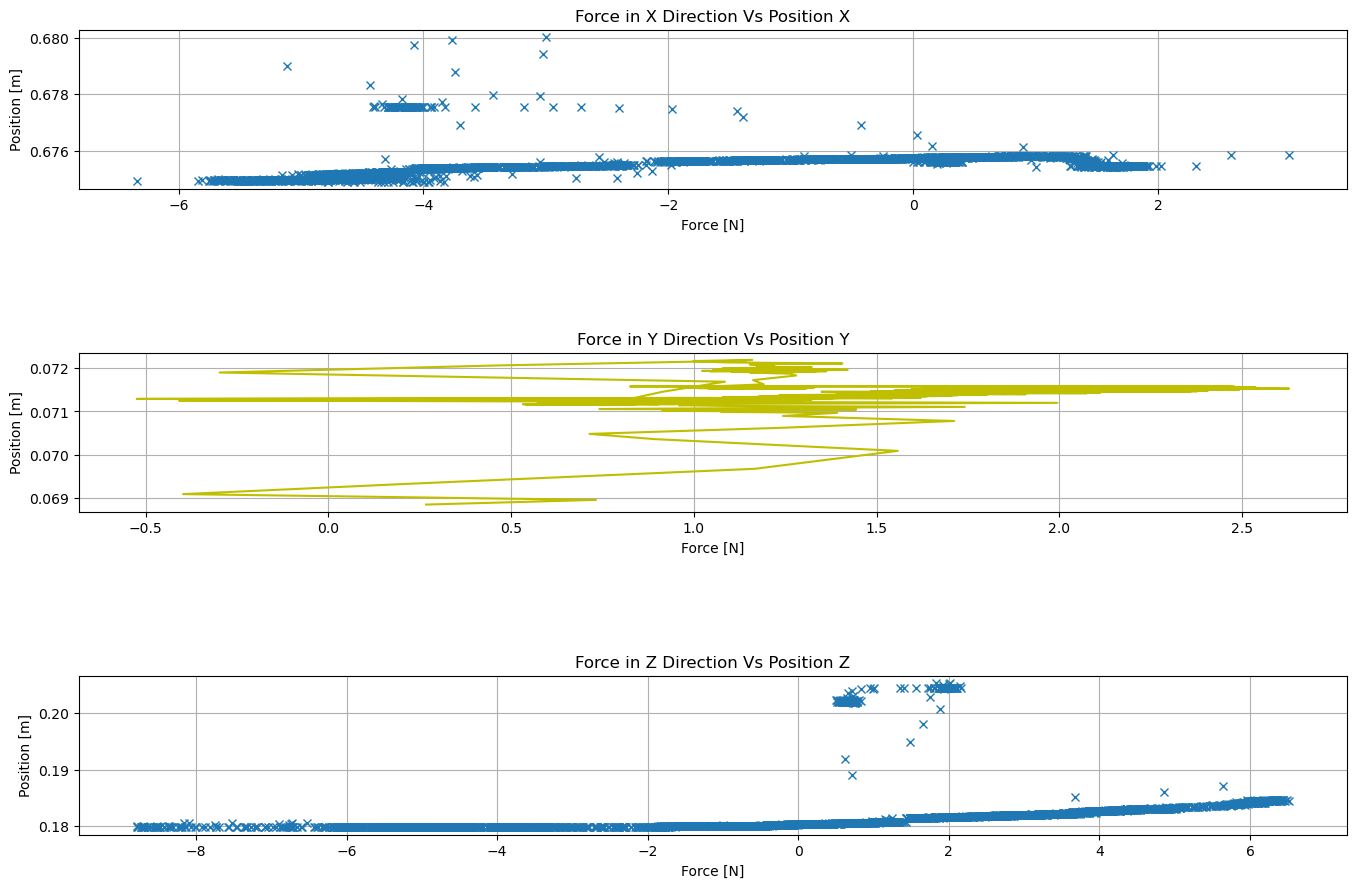

In [17]:
plt.subplot(3,1,1)
plt.plot(df.Fx, df.x, 'x')
plt.ylabel("Position [m]")
plt.xlabel("Force [N]")
plt.title("Force in X Direction Vs Position X")
plt.grid()
plt.tight_layout()

plt.subplot(3,1,2)
plt.plot(df.Fy, df.y, 'y')
plt.ylabel("Position [m]")
plt.xlabel("Force [N]")
plt.title("Force in Y Direction Vs Position Y")
plt.grid()
plt.tight_layout()

plt.subplot(3,1,3)
plt.plot(df.Fz, df.z, 'x')
plt.ylabel("Position [m]")
plt.xlabel("Force [N]")
plt.title("Force in Z Direction Vs Position Z")
plt.grid()
plt.tight_layout()
plt.gcf().set_size_inches(15,10)


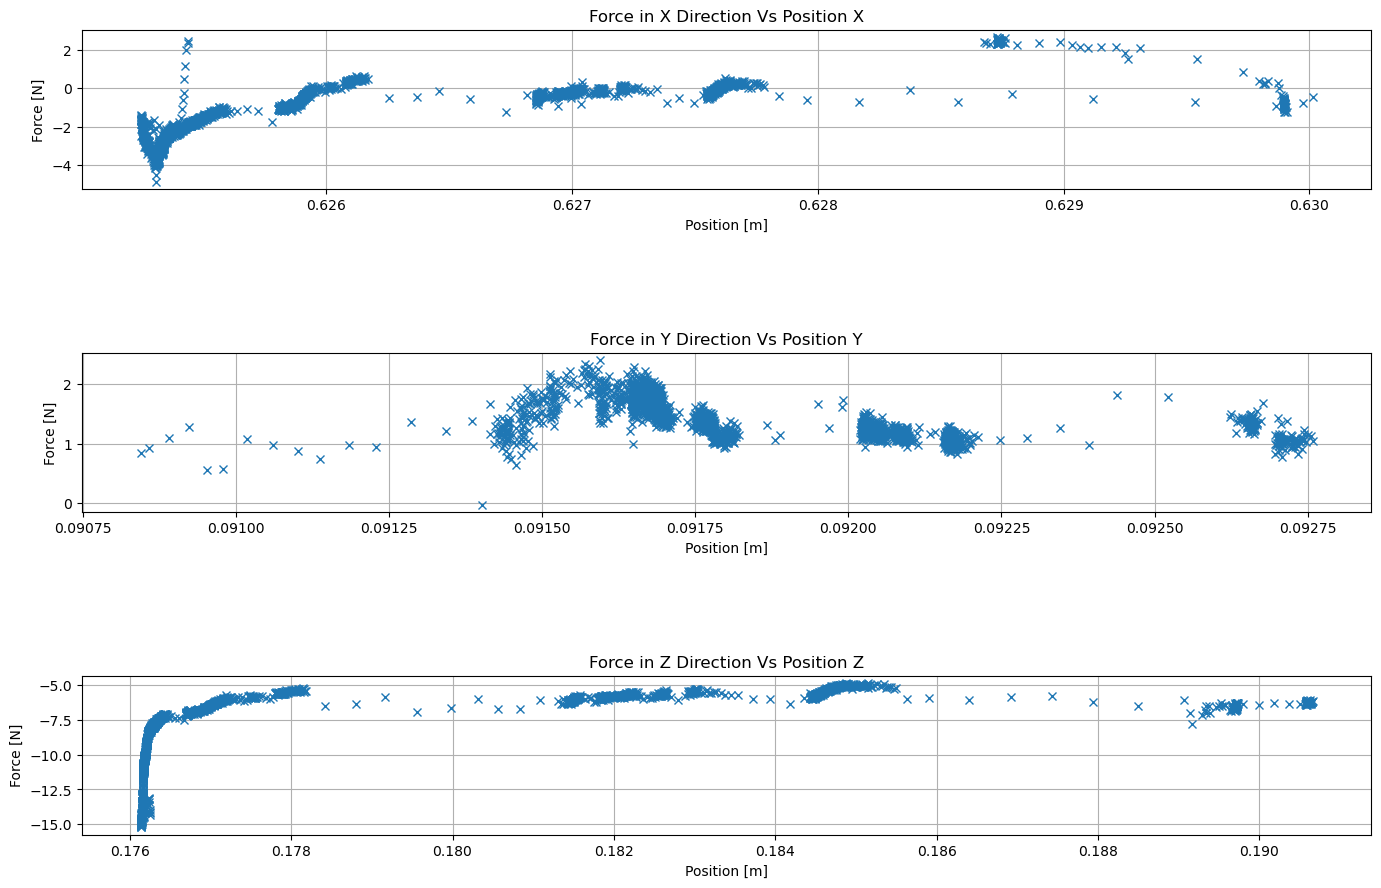

In [52]:
plt.subplot(3,1,1)
plt.plot(df.x, df.Fx+2, 'x')
plt.ylabel("Force [N]")
plt.xlabel("Position [m]")
plt.title("Force in X Direction Vs Position X")
plt.grid()
plt.tight_layout()

plt.subplot(3,1,2)
plt.plot(df.y, df.Fy+0.28, 'x')
plt.ylabel("Force [N]")
plt.xlabel("Position [m]")
plt.title("Force in Y Direction Vs Position Y")
plt.grid()
plt.tight_layout()

plt.subplot(3,1,3)
plt.plot(df.z, df.Fz-6.7, 'x')
plt.ylabel("Force [N]")
plt.xlabel("Position [m]")
plt.title("Force in Z Direction Vs Position Z")
plt.grid()
plt.tight_layout()
plt.gcf().set_size_inches(15,10)


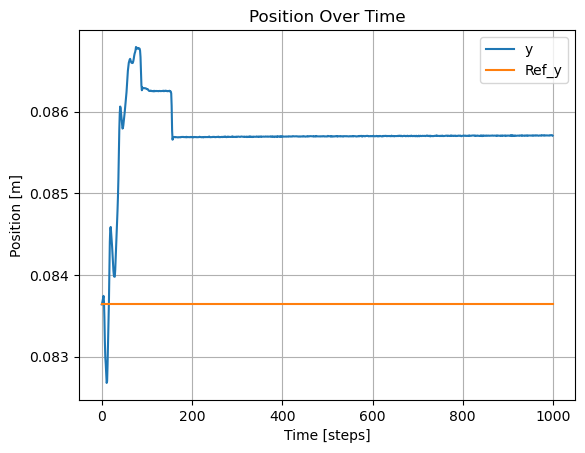

In [7]:
plt.plot(df.y[0:1000], label = "y")
plt.plot(df.ref_y[0:1000], label="Ref_y")
plt.title("Position Over Time")
plt.xlabel("Time [steps]")
plt.ylabel("Position [m]")
plt.legend()
plt.grid()

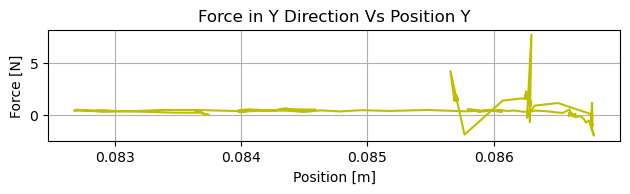

In [8]:
plt.subplot(3,1,2)
plt.plot(df.y[0:1000], df.Fy[0:1000]+0.28, 'y')
plt.ylabel("Force [N]")
plt.xlabel("Position [m]")
plt.title("Force in Y Direction Vs Position Y")
plt.grid()
plt.tight_layout()

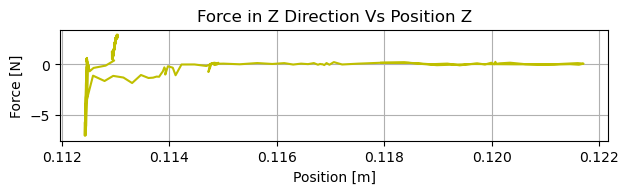

In [9]:
plt.subplot(3,1,2)
plt.plot(df.z[0:1000], df.Fz[0:1000]+0.28, 'y')
plt.ylabel("Force [N]")
plt.xlabel("Position [m]")
plt.title("Force in Z Direction Vs Position Z")
plt.grid()
plt.tight_layout()

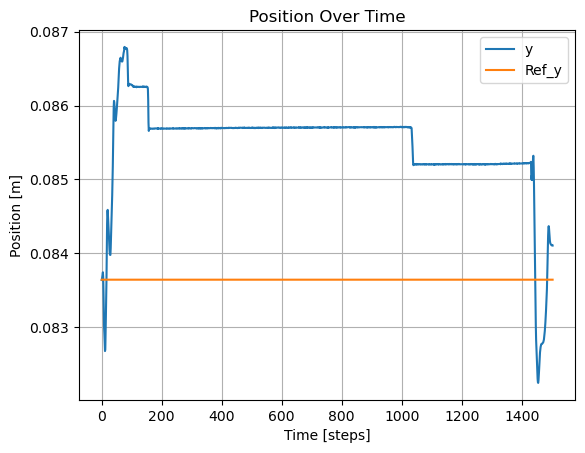

In [10]:
plt.plot(df.y, label = "y")
plt.plot(df.ref_y, label="Ref_y")
plt.title("Position Over Time")
plt.xlabel("Time [steps]")
plt.ylabel("Position [m]")
plt.legend()
plt.grid()

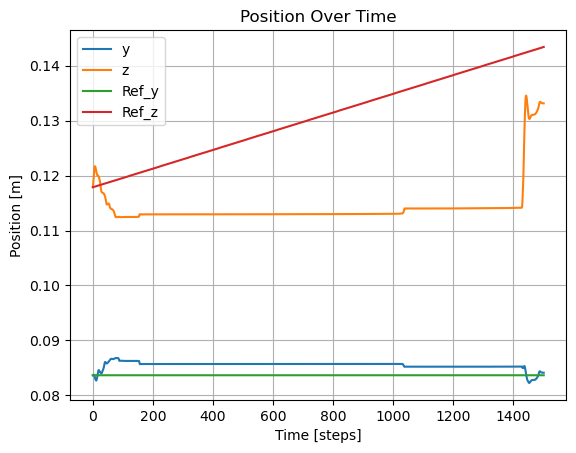

In [11]:
# plt.plot(df.x, label = "x")
plt.plot(df.y, label = "y")
plt.plot(df.z, label = "z")
# plt.plot(df.ref_x, label="Ref_x")
plt.plot(df.ref_y, label="Ref_y")
plt.plot(df.ref_z, label="Ref_z")
plt.title("Position Over Time")
plt.xlabel("Time [steps]")
plt.ylabel("Position [m]")
plt.legend()
plt.grid()

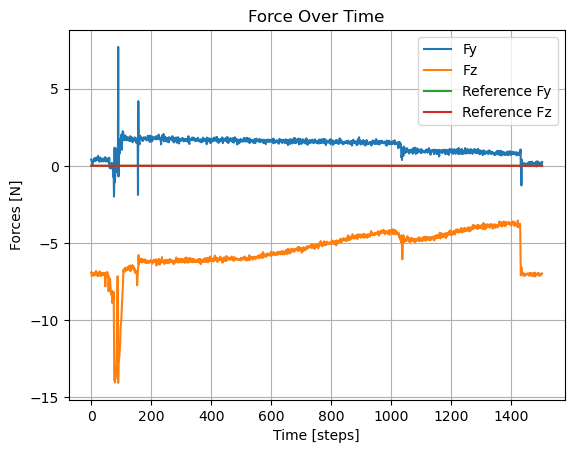

In [12]:
# plt.plot(df.Fx, label = "Fx")
# plt.plot(df.Fy, label = "Fy")
# plt.plot(df.Fz, label = "Fz")
# plt.plot(df.Fx+2, label = "Fx")
plt.plot(df.Fy+0.28, label = "Fy")
plt.plot(df.Fz-6.8, label = "Fz")
# plt.plot(df.ref_Fx, label="Reference Fx")
plt.plot(df.ref_Fy, label="Reference Fy")
plt.plot(df.ref_Fz, label="Reference Fz")
plt.title("Force Over Time")
plt.xlabel("Time [steps]")
plt.ylabel("Forces [N]")
plt.legend()
plt.grid()